In [12]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [14]:
data_cap = {
    'Sector': ['Wind Power', 'Solar Power', 'Small Hydro Power',
               'Biomass (Bagasse) Cogeneration', 'Biomass(Non-bagasse) Cogeneration',
               'Waste to Energy', 'Waste to Energy (Off-grid)', 'Total'],
    'Cum_2014': [21042.58, 2821.91, 3803.68, 7419.23, 531.82, 90.58, 139.79, 35849.59],
    '2014-15': [2311.77, 1171.62, 251.68, 295.67, 60.05, 0.00, 9.71, 4100.50],
    '2015-16': [3423.05, 3130.36, 218.11, 304.85, 59.24, 0.00, 5.69, 7141.30],
    '2016-17': [5502.37, 5658.63, 106.38, 161.95, 2.20, 23.50, 11.77, 11466.81],
    '2017-18': [1865.23, 9563.69, 105.95, 519.10, 9.50, 24.22, 5.55, 12093.24],
    '2018-19': [1480.97, 6750.97, 107.34, 402.70, 12.00, 0.00, 6.58, 8760.56],
    '2019-20': [2117.79, 6510.06, 90.01, 97.00, 0.00, 9.34, 19.11, 8843.31],
    '2020-21': [1503.30, 5628.80, 103.65, 173.37, 97.24, 21.00, 20.75, 7548.11],
    '2021-22': [1110.53, 12760.50, 62.09, 59.69, 0.00, 54.50, 34.66, 14081.97],
    '2022-23': [2275.55, 12783.80, 95.40, 0.00, 42.40, 25.00, 52.28, 15274.43],
    '2023-24': [3253.38, 15033.24, 58.95, 0.00, 107.34, 1.60, 30.17, 18484.68],
    '2024-25': [4151.31, 23832.87, 97.30, 387.76, 0.00, 59.60, 194.81, 28723.65],
    '2025-26': [5094.68, 37957.90, 70.81, 0.00, 14.20, 0.00, 17.45, 43155.04],
    'Cum_2026': [56094.84, 150260.72, 5171.36, 9821.32, 1047.85, 324.24, 553.12, 223273.45]
}

df_cap = pd.DataFrame(data_cap)
years = ['2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025','2026']

def calculate_cumulative(row):
    cum = row['Cum_2014']
    cumulatives = [cum]
    for col in ['2014-15','2015-16','2016-17','2017-18','2018-19',
                 '2019-20','2020-21','2021-22','2022-23','2023-24','2024-25','2025-26']:
        cum += row[col]
        cumulatives.append(cum)
    return cumulatives

key_sectors = ['Wind Power', 'Solar Power', 'Total']
df_key = df_cap[df_cap['Sector'].isin(key_sectors)].copy()
df_key['cumulatives'] = df_key.apply(calculate_cumulative, axis=1)

plot_data = []
for _, row in df_key.iterrows():
    for i, cap in enumerate(row['cumulatives']):
        plot_data.append({'Year': years[i], 'Capacity_GW': cap/1000, 'Sector': row['Sector']})

df_plot = pd.DataFrame(plot_data)


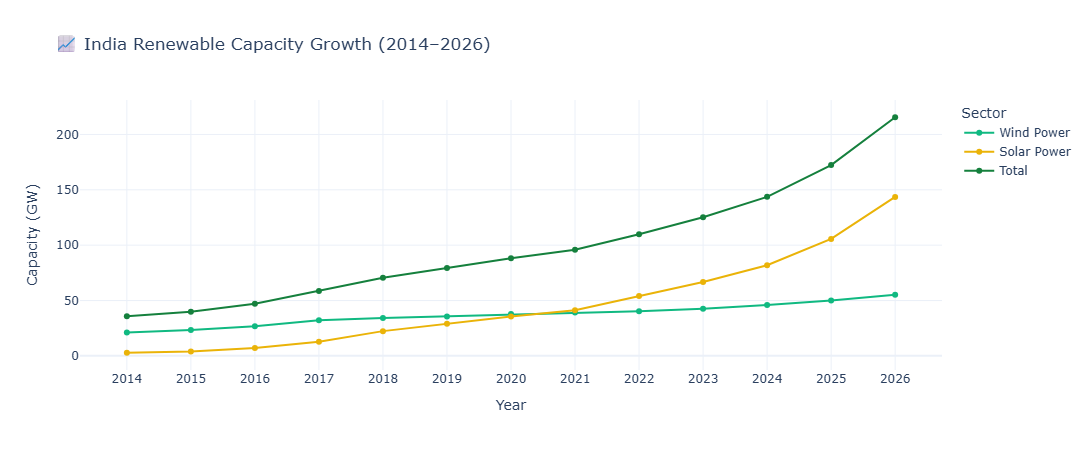

In [15]:
fig = px.line(
    df_plot, x='Year', y='Capacity_GW', color='Sector', markers=True,
    title='📈 India Renewable Capacity Growth (2014–2026)',
    color_discrete_map={
        'Solar Power': '#EAB308',
        'Wind Power':  '#10B981',
        'Total':       '#15803D'
    }
)
fig.update_layout(template='plotly_white', hovermode='x unified',
                  yaxis_title='Capacity (GW)', height=450)
fig.show()

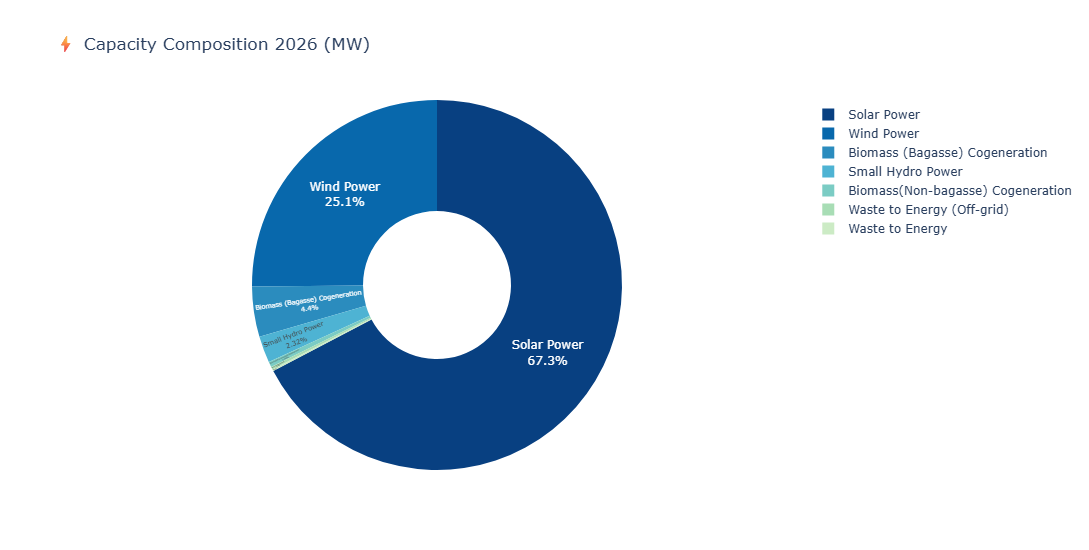

In [16]:
pie_data = df_cap[df_cap['Sector'] != 'Total'][['Sector','Cum_2026']].copy()

fig2 = px.pie(
    pie_data, values='Cum_2026', names='Sector', hole=0.4,
    title='⚡ Capacity Composition 2026 (MW)',
    color_discrete_sequence=px.colors.sequential.GnBu_r
)
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.update_layout(template='plotly_white', height=550)
fig2.show()

In [18]:
raw_text = """1 28 Andhra Pradesh 164.51 4415.78 378.10 134.57 53.16 49.19 615.02 6382.54 774.5 249.42 88.34 7494.80 3290.00 15980.11
2 12 Arunachal Pradesh 140.61 0 0 0 0 0 0.00 1.27 6.68 0 7.49 15.44 1865.00 2021.05
3 18 Assam 34.11 0 0 8.00 0 0 8.00 216.26 344.2 0 9.71 570.17 346.00 958.28
4 10 Bihar 70.70 0 112.50 31.40 0 1.32 145.22 196.06 218 0 21.28 435.34 0 651.26
5 22 Chhattisgarh 100.90 0 272.09 7.00 0 10.83 289.92 1254.41 167.6 0 390.73 1812.74 120.00 2323.56
6 30 Goa 0.05 0 0 0 1.94 0 1.94 8.51 71.5 0 1.49 81.50 0 83.49
7 24 Gujarat 113.30 15642.26 65.30 12.00 7.50 45.05 129.85 20974.68 6881.8 1273.43 173.01 29302.92 1990.00 47178.33
8 6 Haryana 73.50 0 151.40 125.46 11.20 41.78 329.84 267.76 1188.3 0 1152.32 2608.38 0 3011.72
9 2 Himachal Pradesh 1013.46 0 0 9.20 0 1.00 10.20 257 66.7 0 34.58 358.28 11421.02 12802.96
10 1 Jammu & Kashmir 189.93 0 0 5.00 0 0 5.00 2.49 42.2 0 34.79 79.48 3360.00 3634.41
11 20 Jharkhand 4.05 0 0 19.10 0 1.04 20.14 21 94.9 0 139.5 255.40 210.00 489.59
12 29 Karnataka 1284.73 8730.14 1868.91 20.20 1.00 26.94 1917.05 9855.78 842.9 358.85 44.11 11101.64 3689.20 26722.76
13 32 Kerala 276.52 71.52 0 2.27 0 0.23 2.50 340.26 1850.4 0 24.93 2215.59 2008.15 4574.28
15 23 Madhya Pradesh 123.71 3679.15 92.50 18.85 15.40 32.71 159.46 4990.18 893.1 0 102.04 5985.32 2235.00 12182.64
16 27 Maharashtra 384.28 5927.21 2907.30 16.40 12.59 63.68 2999.97 12171.3 5442.3 0 2008.57 19622.17 3047.00 31980.63
17 14 Manipur 5.45 0 0 0 0 0 0.00 0.6 10.6 0 6.32 17.52 105.00 127.97
18 17 Meghalaya 55.03 0 0 13.80 0 0 13.80 0 0.21 0 4.07 4.28 322.00 395.11
19 15 Mizoram 45.47 0 0 0 0 0 0.00 22 5.3 0 6.39 33.69 60.00 139.16
20 13 Nagaland 32.67 0 0 0 0 0 0.00 0 1 0 2.34 3.34 75.00 111.01
21 21 Odisha 140.63 0 50.40 8.82 0 5.00 64.22 662.52 156.3 0 64.62 883.44 2154.55 3242.84
22 3 Punjab 176.10 0 299.50 237.79 10.75 34.55 582.59 886.77 581.2 0 116.97 1584.94 1096.30 3439.93
23 8 Rajasthan 23.85 5349.15 134.15 2.00 74.50 11.77 222.42 36125.95 2090.4 1980 816.27 41012.62 412.50 47020.54
24 11 Sikkim 55.11 0 0 0 0 0 0.00 0.52 5.12 0 1.92 7.56 2282.00 2344.67
25 33 Tamil Nadu 123.05 12147.23 969.10 52.05 6.40 27.57 1055.12 11972.82 1532.3 0 74.55 13579.67 2203.20 29108.27
26 36 Telangana 89.67 128.10 158.10 23.74 45.80 14.47 242.11 4360.49 695.9 0 8.71 5065.10 2405.60 7930.58
27 16 Tripura 16.01 0 0 0 0 0 0.00 7.09 12.2 0 16.25 35.54 0 51.55
28 9 Uttar Pradesh 50.60 0 1985.50 184.76 0 159.63 2329.89 3048.33 715.3 0 359.51 4123.14 501.60 7005.23
29 5 Uttarakhand 233.82 0 72.72 71.92 0 16.85 161.49 541.05 273.71 0 23.13 837.89 4785.35 6018.55
30 19 West Bengal 98.50 0 300.00 43.52 0 8.34 351.86 240.35 67.13 0 13.14 320.62 1341.20 2112.18"""

lines = raw_text.split("\n")
clean_lines, buffer = [], ""
for line in lines:
    line = line.strip()
    if not line: continue
    if re.match(r"^\d+", line):
        if buffer: clean_lines.append(buffer)
        buffer = line
    else:
        buffer += " " + line
if buffer: clean_lines.append(buffer)

data_state = []
for line in clean_lines:
    parts = line.split()
    state_parts, numeric_parts = [], []
    for p in parts[1:]:
        if re.match(r"^\d+(\.\d+)?$", p):
            numeric_parts.append(float(p))
        else:
            state_parts.append(p)
    data_state.append([" ".join(state_parts)] + numeric_parts)

df_state = pd.DataFrame(data_state)
df_state = df_state.drop(df_state.columns[[1]], axis=1)
df_state.columns = ["State","Small Hydro","Wind","Biomass Bagasse","Biomass Non-Bagasse",
                    "Waste","Waste Offgrid","Bio Total","Solar Ground","Solar RTS",
                    "Solar Hybrid","Solar Offgrid","Solar Total","Large Hydro","Total Capacity"]
df_state = df_state[["State","Solar Total","Wind","Small Hydro","Bio Total","Large Hydro","Total Capacity"]]
for col in df_state.columns:
    if col != "State":
        df_state[col] = pd.to_numeric(df_state[col], errors='coerce')


df_state.head(3)

,State,Solar Total,Wind,Small Hydro,Bio Total,Large Hydro,Total Capacity
0,Andhra Pradesh,7494.80,4415.78,164.51,615.02,3290.0,15980.11
1,Arunachal Pradesh,15.44,0.00,140.61,0.00,1865.0,2021.05
2,Assam,570.17,0.00,34.11,8.00,346.0,958.28


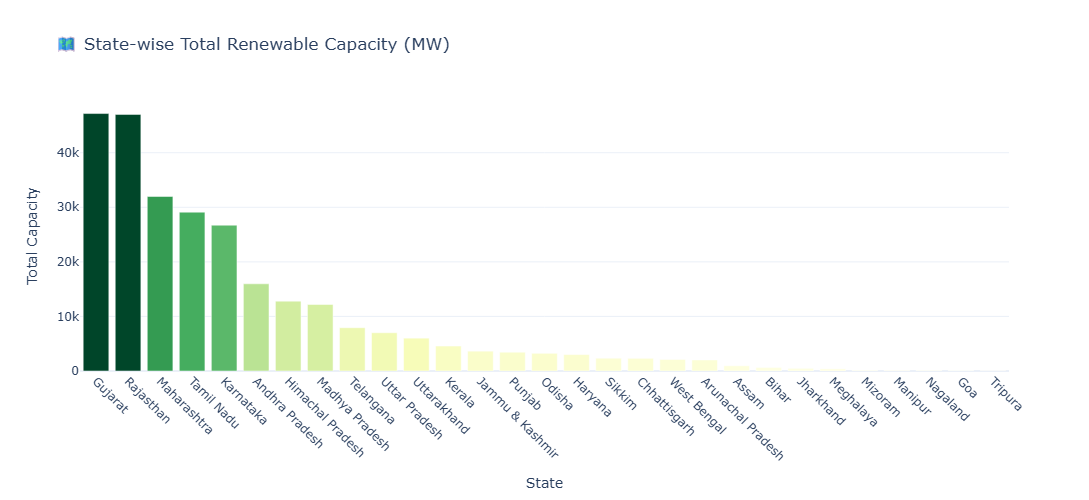

In [19]:
fig_bar = px.bar(
    df_state.sort_values("Total Capacity", ascending=False),
    x="State", y="Total Capacity",
    color="Total Capacity",
    color_continuous_scale="YlGn",
    title="🗺️ State-wise Total Renewable Capacity (MW)"
)
fig_bar.update_layout(template='plotly_white', xaxis_tickangle=45,
                      height=500, coloraxis_showscale=False)
fig_bar.show()

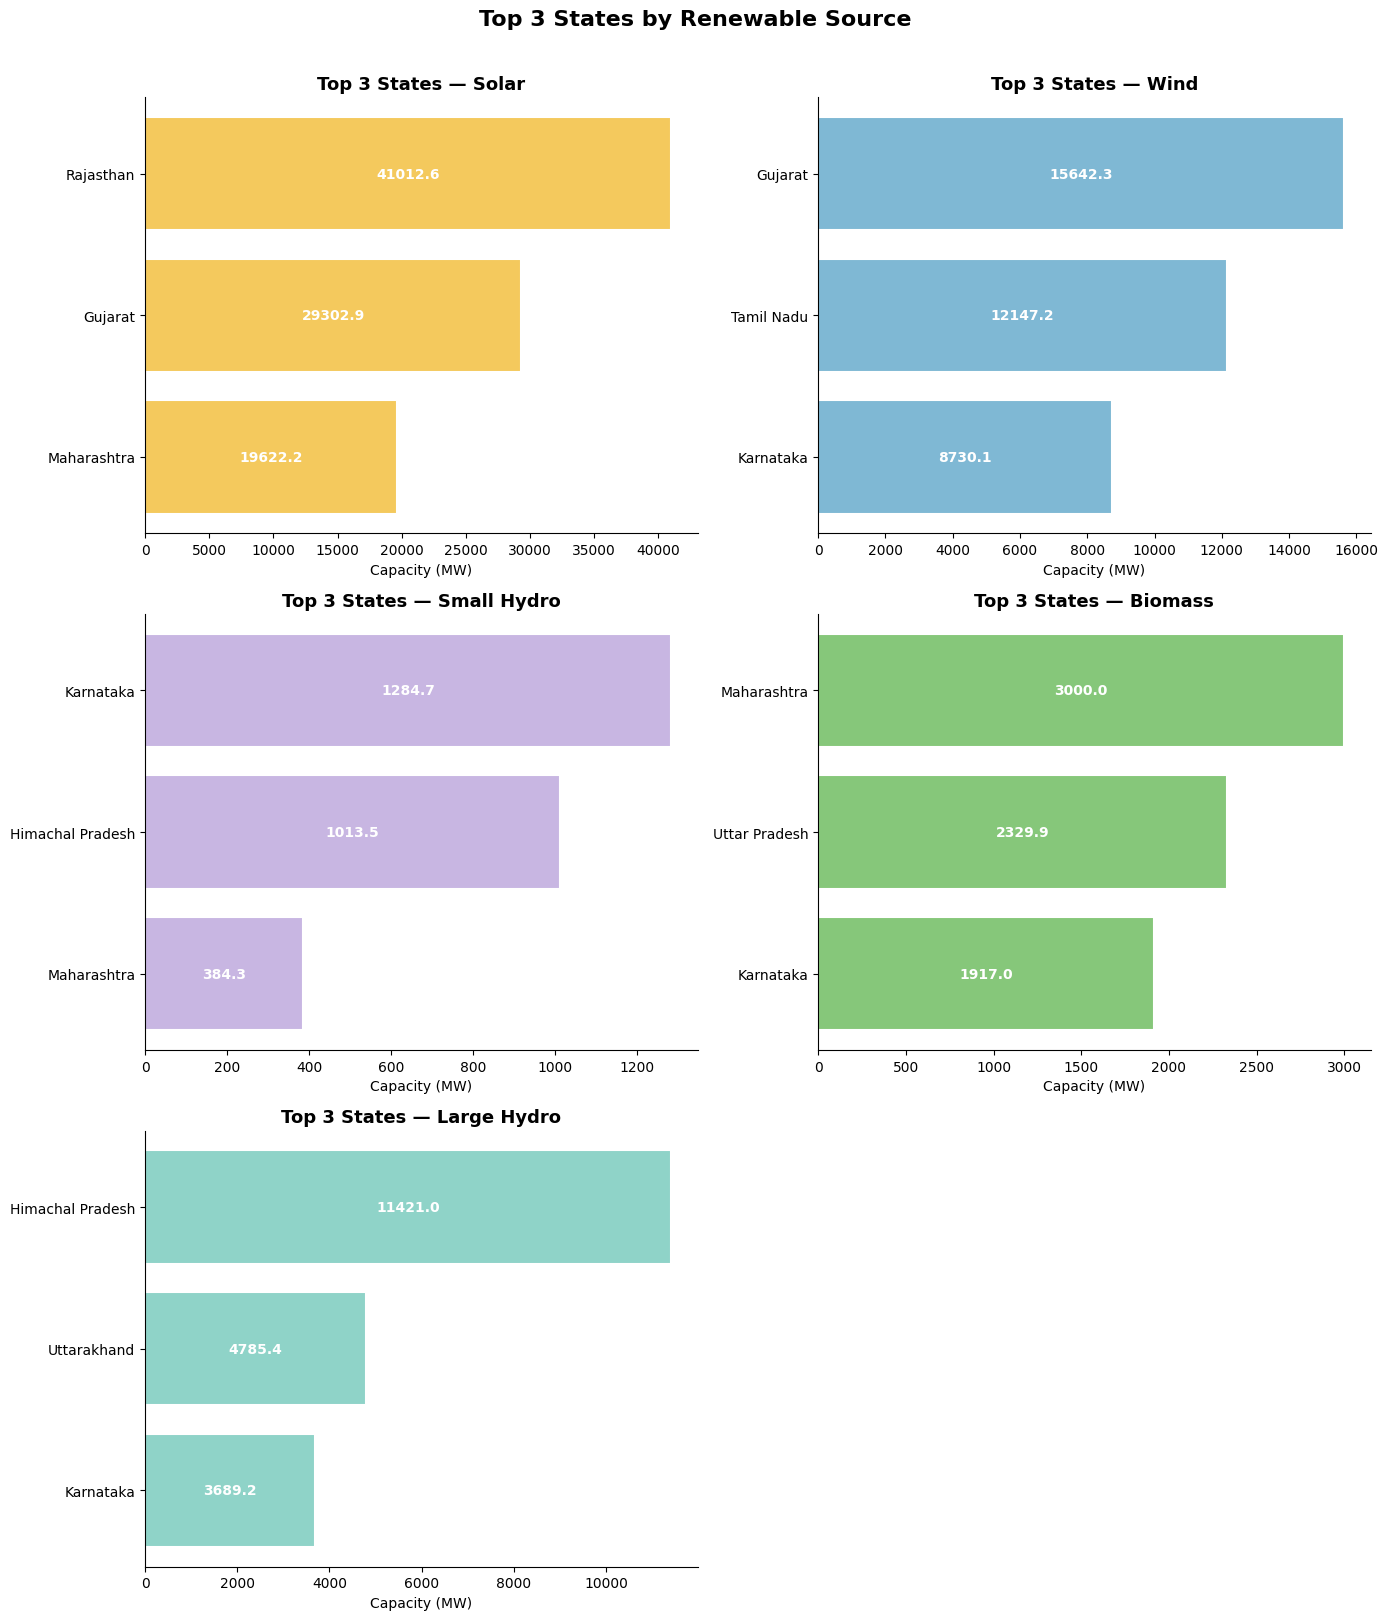

In [20]:
source_cols   = ["Solar Total","Wind","Small Hydro","Bio Total","Large Hydro"]
source_labels = {"Solar Total":"Solar","Wind":"Wind","Small Hydro":"Small Hydro",
                 "Bio Total":"Biomass","Large Hydro":"Large Hydro"}
source_colors = {"Solar Total":"#F4C95D","Wind":"#7FB8D4","Small Hydro":"#C8B6E2",
                 "Bio Total":"#86C77A","Large Hydro":"#8FD3C8"}

fig_top3, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, source in enumerate(source_cols):
    top3 = df_state.nlargest(3, source)[["State", source]].sort_values(source)
    axes[i].barh(top3["State"], top3[source],
                 color=source_colors[source], edgecolor='white', linewidth=1.5)
    for j, (val, state) in enumerate(zip(top3[source], top3["State"])):
        axes[i].text(val * 0.5, j, f"{val:.1f}", va='center', ha='center',
                     fontsize=10, color='white', fontweight='bold')
    axes[i].set_title(f"Top 3 States — {source_labels[source]}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Capacity (MW)")
    axes[i].spines[['top','right']].set_visible(False)

if len(source_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Top 3 States by Renewable Source", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
df_gen = pd.DataFrame({
    "Year":       ["2015-16","2016-17","2017-18","2018-19","2019-20",
                   "2020-21","2021-22","2022-23","2023-24","2024-25","2025-26"],
    "Coal":       [896.3, 944, 986.6, 1022.3, 994.2, 981.44, 1078.58, 1182.1, 1294.85, 1331.87, 1162.11],
    "Oil & Gas":  [47.5, 49.5, 50.6, 50, 48.61, 51.07, 36.13, 24.11, 31.7, 32.02, 24.83],
    "Nuclear":    [37.4, 37.9, 38.3, 37.8, 46.38, 43.03, 47.11, 45.86, 47.94, 56.68, 50.07],
    "Hydro":      [121.4, 122.4, 126.1, 134.9, 155.97, 150.3, 151.63, 162.1, 134.05, 148.63, 157.69],
    "Wind":       [33, 46, 52.7, 62, 64.64, 60.15, 68.64, 71.81, 83.39, 83.35, 100.21],
    "Solar":      [7.4, 13.5, 25.9, 39.3, 50.1, 60.4, 73.48, 102.01, 115.98, 144.15, 153.91],
    "Bio Power":  [16.95, 14.44, 15.61, 16.75, 14.21, 16.44, 18.32, 18.55, 16.99, 15.94, 14.06],
    "Small-Hydro":[8.4, 7.9, 7.7, 8.7, 9.37, 10.26, 10.46, 11.17, 9.49, 11.57, 11.02],
    "Total":      [1168, 1236, 1304, 1372, 1383, 1373, 1484, 1618, 1734, 1824, 1674],
})

renewable    = ["Hydro","Wind","Solar","Bio Power","Small-Hydro"]
nonrenewable = ["Coal","Oil & Gas","Nuclear"]
df_gen["Renewable"]     = df_gen[renewable].sum(axis=1)
df_gen["Non-Renewable"] = df_gen[nonrenewable].sum(axis=1)
df_gen["RE %"]          = df_gen["Renewable"] / df_gen["Total"] * 100

print("Generation data ready ✅")
df_gen.head(3)

Generation data ready ✅


,Year,Coal,Oil & Gas,Nuclear,Hydro,Wind,Solar,Bio Power,Small-Hydro,Total,Renewable,Non-Renewable,RE %
0,2015-16,896.3,47.5,37.4,121.4,33.0,7.4,16.95,8.4,1168,187.15,981.2,16.023116
1,2016-17,944.0,49.5,37.9,122.4,46.0,13.5,14.44,7.9,1236,204.24,1031.4,16.524272
2,2017-18,986.6,50.6,38.3,126.1,52.7,25.9,15.61,7.7,1304,228.01,1075.5,17.485429


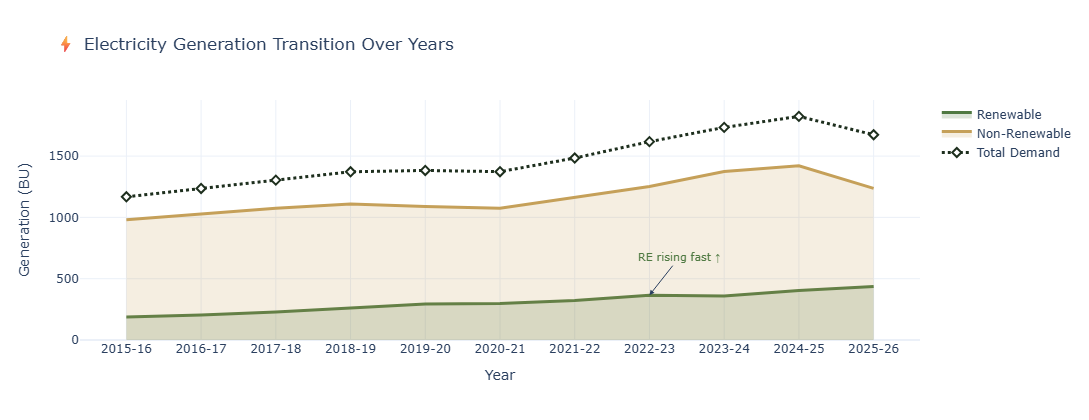

In [22]:
fig_area = go.Figure()

fig_area.add_trace(go.Scatter(
    x=df_gen["Year"], y=df_gen["Renewable"],
    mode="lines", name="Renewable",
    line=dict(color="#4F7942", width=3),
    fill="tozeroy", fillcolor="rgba(79,121,66,0.20)"
))
fig_area.add_trace(go.Scatter(
    x=df_gen["Year"], y=df_gen["Non-Renewable"],
    mode="lines", name="Non-Renewable",
    line=dict(color="#C5A059", width=3),
    fill="tozeroy", fillcolor="rgba(197,160,89,0.18)"
))
fig_area.add_trace(go.Scatter(
    x=df_gen["Year"], y=df_gen["Total"],
    mode="lines+markers", name="Total Demand",
    line=dict(color="#1E2F1E", width=3, dash="dot"),
    marker=dict(size=7, symbol="diamond", color="#ffffff",
                line=dict(color="#1E2F1E", width=2))
))
fig_area.add_annotation(
    x="2022-23", y=float(df_gen.loc[df_gen["Year"]=="2022-23","Renewable"].iloc[0]),
    text="RE rising fast ↑", showarrow=True, arrowhead=2, ax=30, ay=-38,
    font=dict(size=11, color="#4F7942")
)
fig_area.update_layout(
    title="⚡ Electricity Generation Transition Over Years",
    template="plotly_white", height=420,
    xaxis_title="Year", yaxis_title="Generation (BU)"
)
fig_area.show()

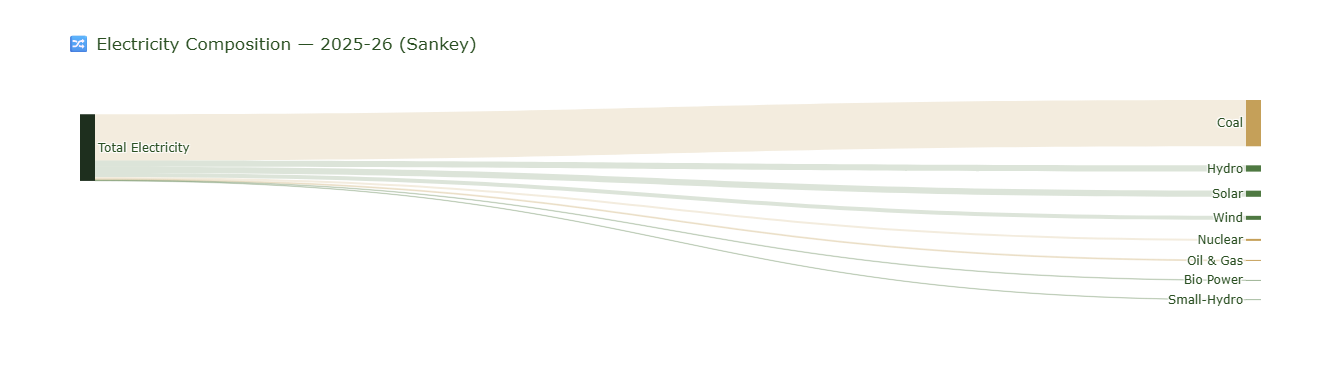

In [23]:
last = df_gen[df_gen["Year"] == "2025-26"].iloc[0]
sources_list = ["Coal","Oil & Gas","Nuclear","Hydro","Wind","Solar","Bio Power","Small-Hydro"]
vals = [float(last[s]) for s in sources_list]
labels = ["Total Electricity"] + sources_list

node_colors = ["#1E2F1E","#C5A059","#C5A059","#C5A059",
               "#4F7942","#4F7942","#4F7942","#4F7942","#4F7942"]
link_colors = ["rgba(197,160,89,0.20)"]*3 + ["rgba(79,121,66,0.20)"]*5

fig_sankey = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=25, thickness=15,
              line=dict(color="rgba(0,0,0,0)", width=0),
              label=labels, color=node_colors),
    link=dict(source=[0]*len(sources_list),
              target=list(range(1, len(sources_list)+1)),
              value=vals, color=link_colors)
))
fig_sankey.update_layout(
    title="🔀 Electricity Composition — 2025-26 (Sankey)",
    font=dict(size=12, color="#2a4f22"),
    height=380
)
fig_sankey.show()

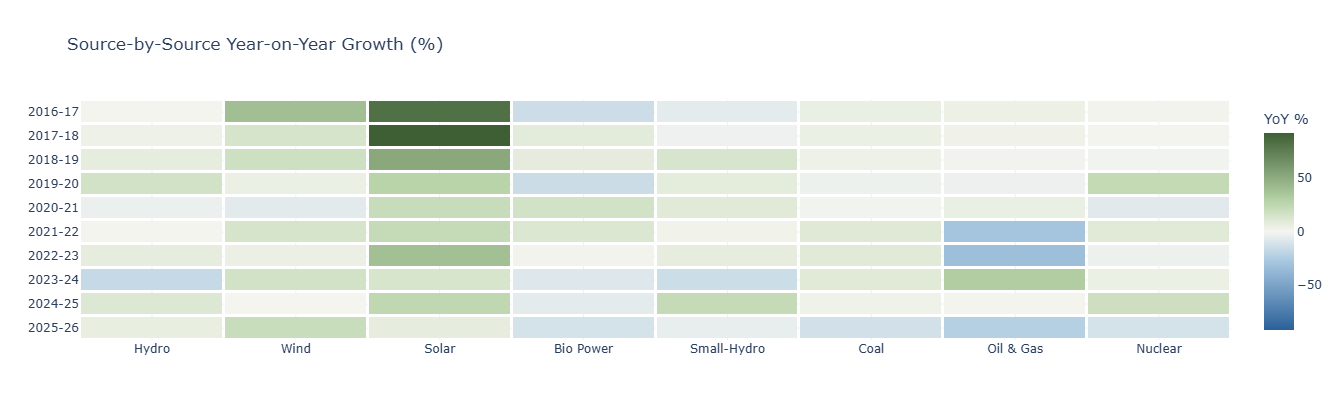

In [25]:
all_sources = ["Hydro","Wind","Solar","Bio Power","Small-Hydro","Coal","Oil & Gas","Nuclear"]
pivot = df_gen.set_index("Year")[all_sources]
heat  = (pivot.pct_change() * 100).iloc[1:].round(1)

fig_heat = go.Figure(data=go.Heatmap(
    z=heat.values,
    x=heat.columns.tolist(),
    y=heat.index.tolist(),
    colorscale=[
        [0.0,  "#2A6099"], [0.35, "#A8C8E0"],
        [0.5,  "#F5F5F0"], [0.65, "#B8D4A8"], [1.0,  "#3E5F34"]
    ],
    zmid=0,
    colorbar=dict(title=dict(text="YoY %")),
    hovertemplate="Source: %{x}<br>Year: %{y}<br>Growth: %{z:.1f}%<extra></extra>",
    xgap=3, ygap=3,
))
fig_heat.update_layout(
    title="Source-by-Source Year-on-Year Growth (%)",
    template="plotly_white", height=420,
    yaxis=dict(autorange="reversed")
)
fig_heat.show()

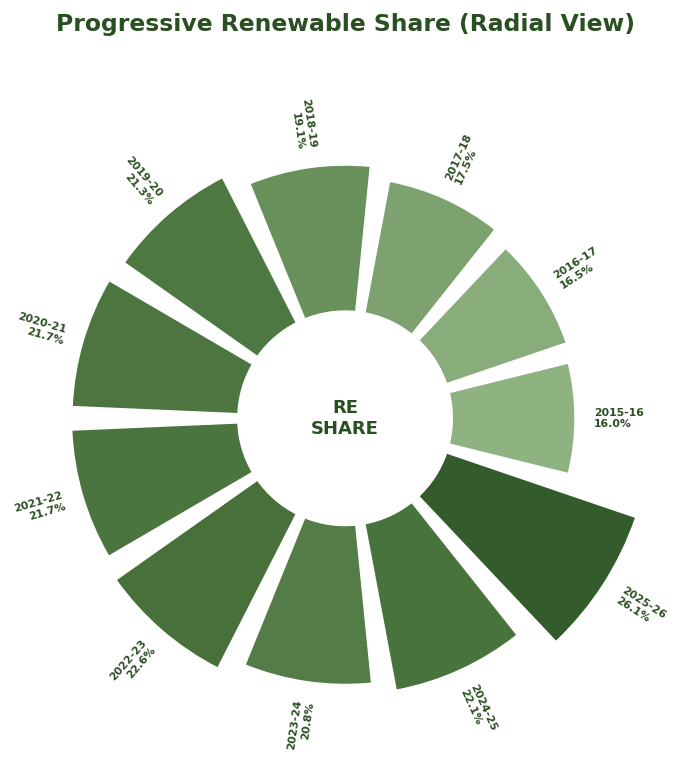

In [27]:
labels_r = df_gen["Year"].tolist()
values_r = df_gen["RE %"].tolist()
n = len(labels_r)
angles_r = np.linspace(0, 2 * np.pi, n, endpoint=False)
lower = 14

norm = plt.Normalize(vmin=min(values_r) - 2, vmax=max(values_r) + 2)
cmap = mcolors.LinearSegmentedColormap.from_list("sage", ["#a8c89a","#4F7942","#2a4f22"])

fig_radial, ax = plt.subplots(figsize=(6, 6), dpi=130, subplot_kw=dict(polar=True))
fig_radial.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

ax.bar(angles_r, values_r, width=(2*np.pi/n)*0.85, bottom=lower,
       color=[cmap(norm(v)) for v in values_r], edgecolor="white", linewidth=0.8)

for angle, height, label, value in zip(angles_r, values_r, labels_r, values_r):
    rotation   = np.rad2deg(angle)
    alignment  = "right" if 90 < rotation < 270 else "left"
    display_rot = rotation + 180 if 90 < rotation < 270 else rotation
    ax.text(angle, lower + height + 2.5, f"{label}\n{value:.1f}%",
            ha=alignment, va="center", rotation=display_rot,
            rotation_mode="anchor", fontsize=6, fontweight="bold", color="#2a4f22")

ax.text(0, 0, "RE\nSHARE", ha="center", va="center",
        fontsize=10, fontweight="900", color="#2a4f22")
plt.title("Progressive Renewable Share (Radial View)", fontsize=13,
          fontweight="bold", pad=20, color="#2a4f22")
plt.tight_layout()
plt.show()

In [30]:
# Expected from installed capacity
cap_years = ['2015-16','2016-17','2017-18','2018-19','2019-20',
             '2020-21','2021-22','2022-23','2023-24','2024-25','2025-26']

total_row = pd.DataFrame(data_cap)[pd.DataFrame(data_cap)['Sector'] == 'Total'].iloc[0]
cumulative_capacity = total_row['Cum_2014'] + total_row[cap_years].cumsum()
expected_generation = (cumulative_capacity * 8760) / 1e6

expected_df = pd.DataFrame({
    'Year': cap_years,
    'Expected_RE_Generation_BU': expected_generation.values
})

# Actual RE from generation data
re_sources_gen = ["Wind","Solar","Bio Power","Small-Hydro"]
actual_re = df_gen[["Year"] + re_sources_gen].copy()
actual_re["Actual_RE_Generation_BU"] = actual_re[re_sources_gen].sum(axis=1)
actual_re = actual_re[["Year","Actual_RE_Generation_BU"]]

plot_df = pd.merge(expected_df, actual_re, on='Year').sort_values("Year").reset_index(drop=True)
plot_df["Gap_BU"]  = plot_df["Expected_RE_Generation_BU"] - plot_df["Actual_RE_Generation_BU"]
plot_df["Gap_Pct"] = (plot_df["Gap_BU"] / plot_df["Expected_RE_Generation_BU"]) * 100


plot_df

,Year,Expected_RE_Generation_BU,Actual_RE_Generation_BU,Gap_BU,Gap_Pct
0,2015-16,376.600196,65.75,310.850196,82.541167
1,2016-17,477.049452,81.84,395.209452,82.844546
2,2017-18,582.986234,101.91,481.076234,82.519313
3,2018-19,659.72874,126.75,532.97874,80.787558
4,2019-20,737.196136,138.32,598.876136,81.237015
5,2020-21,803.317579,147.25,656.067579,81.669765
6,2021-22,926.675636,170.90,755.775636,81.557732
7,2022-23,1060.479643,203.54,856.939643,80.806798
8,2023-24,1222.40544,225.85,996.55544,81.524133
9,2024-25,1474.024614,255.01,1219.014614,82.699746


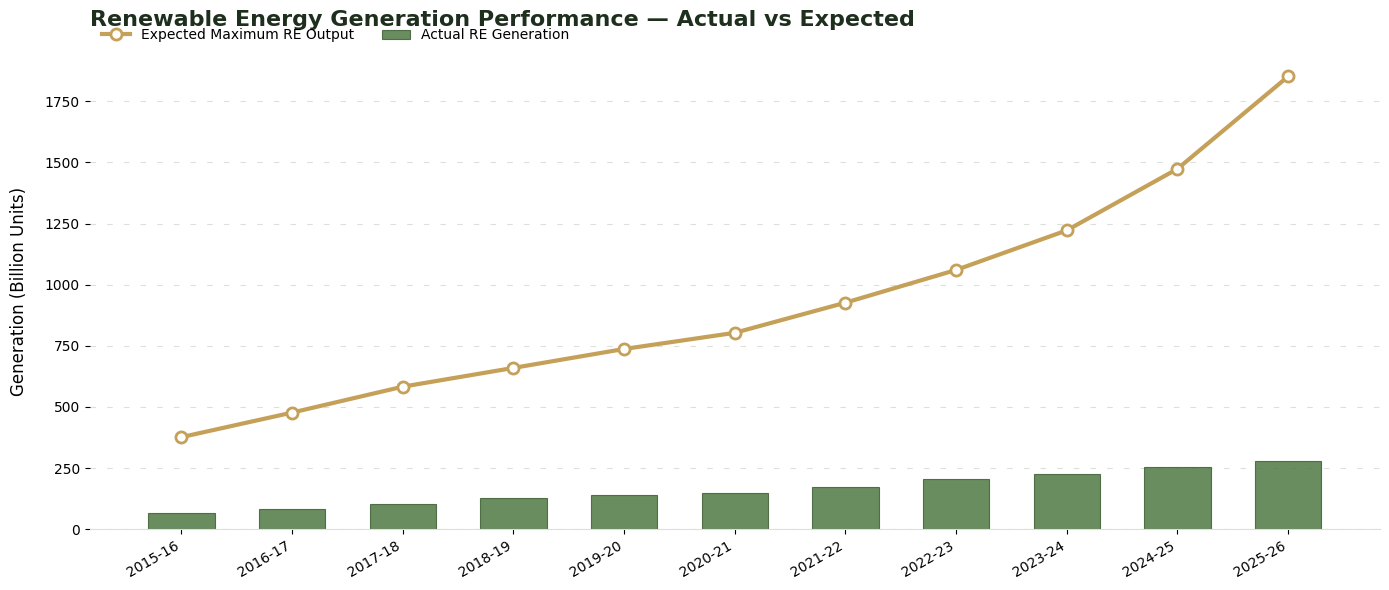

In [34]:
x = np.arange(len(plot_df))
actual   = plot_df["Actual_RE_Generation_BU"].values
expected = plot_df["Expected_RE_Generation_BU"].values

fig_avse, ax = plt.subplots(figsize=(14, 6), dpi=100)
fig_avse.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

ax.bar(x, actual, color="#4F7942", alpha=0.85, width=0.6,
       label="Actual RE Generation", edgecolor="#3E5F34", linewidth=0.8)
ax.plot(x, expected, marker="o", markersize=8, linewidth=3,
        color="#C5A059", markerfacecolor="#FFFFFF",
        markeredgecolor="#C5A059", markeredgewidth=2,
        label="Expected Maximum RE Output")
# ax.fill_between(x, actual, expected, where=expected >= actual,
#                 facecolor="#F9F1E1", alpha=0.5, interpolate=True,
#                 hatch='///', edgecolor="#C5A059", linewidth=0, label="Efficiency Gap")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Year"], fontsize=10, rotation=30, ha='right')
ax.set_title("Renewable Energy Generation Performance — Actual vs Expected",
             fontsize=16, fontweight="bold", loc="left", pad=20, color="#1E2F1E")
ax.set_ylabel("Generation (Billion Units)", fontsize=12, labelpad=12)
ax.legend(frameon=False, ncol=3, loc="upper left",
          bbox_to_anchor=(0, 1.08), fontsize=10)
ax.grid(axis="y", linestyle=(0,(5,10)), alpha=0.4, color="#A8B2A7")
ax.set_axisbelow(True)
for spine in ["top","right","left"]: ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#D8E2D5")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [5]:
    data = {
        'year':      [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025],
        'fiscal':    ['2015-16','2016-17','2017-18','2018-19','2019-20',
                      '2020-21','2021-22','2022-23','2023-24','2024-25','2025-26'],
        'total':     [1168,1236,1304,1372,1383,1373,1484,1618,1734,1824,1674],
        'solar':     [7.4,13.5,25.9,39.3,50.1,60.4,73.48,102.01,115.98,144.15,153.91],
        'wind':      [33.0,46.0,52.7,62.0,60.15,68.64,71.81,83.39,83.35,83.35,100.21],
        'hydro':     [129.8,130.3,133.8,165.34,160.56,162.09,173.27,171.59,143.54,160.20,157.69],
        'bio':       [16.95,14.44,15.61,16.75,14.21,16.44,18.32,16.99,15.94,14.06,14.06],
    }
    df = pd.DataFrame(data)
    # Capacity additions are in MW — convert to GW
    capacity_additions_MW = {
    'Wind':  [3423.05, 5502.37, 1865.23, 1480.97, 2117.79, 1503.30, 1110.53, 2275.55, 3253.38,4151.31,6057.02],
    'Solar': [3130.36, 5658.63, 9563.69, 6750.97, 6510.06, 5628.80, 12760.50, 12783.80, 15033.24,23832.87,44614.25],
    'SHP':   [218.11,  106.38,  105.95,  107.34,  90.01,  103.65,  62.09,  95.40,  58.95,97.30	,70.81],
    'Bio':   [364.09,  164.15,  528.60,  414.70,  97.00,  270.61, 59.69,  42.40,  107.34, 387.76 ,126.06],
    }

    # Cumulative capacity as of 2014 base (MW)
    base_MW = {'Wind': 23354.55, 'Solar':3993.53, 'SHP': 4055.36, 'Bio': 8306.77}

    # Build cumulative GW per year
    import numpy as np
    years = [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
    cap_gw = {}
    for src in ['Wind','Solar','SHP','Bio']:
        cum_mw = base_MW[src]
        gw_list = []
        for addition in capacity_additions_MW[src]:
            cum_mw += addition
            gw_list.append(round(cum_mw / 1000, 2))   # ← MW to GW here
        cap_gw[src] = gw_list

    df['cap_solar'] = cap_gw['Solar']
    df['cap_wind']  = cap_gw['Wind']
    df['cap_hydro'] = cap_gw['SHP']
    df['cap_bio']   = cap_gw['Bio']

    # NOW compute CUF — cap is already in GW, generation is in BU (billion kWh = GWh×1000)
    # BU = GWh/1000, so: CUF = BU / (GW × 8.76)  ← units are consistent
    df['cuf_solar'] = df['solar'] / (df['cap_solar'] * 8.76)
    df['cuf_wind']  = df['wind']  / (df['cap_wind']  * 8.76)
    df['cuf_hydro'] = df['hydro'] / (df['cap_hydro'] * 8.76)
    df['cuf_bio']   = df['bio']   / (df['cap_bio']   * 8.76)
    

    
    for src, cap in [('solar','cap_solar'),('wind','cap_wind'),
                     ('hydro','cap_hydro'),('bio','cap_bio')]:
        df[f'cuf_{src}'] = df[src] / (df[cap] * 8.76)

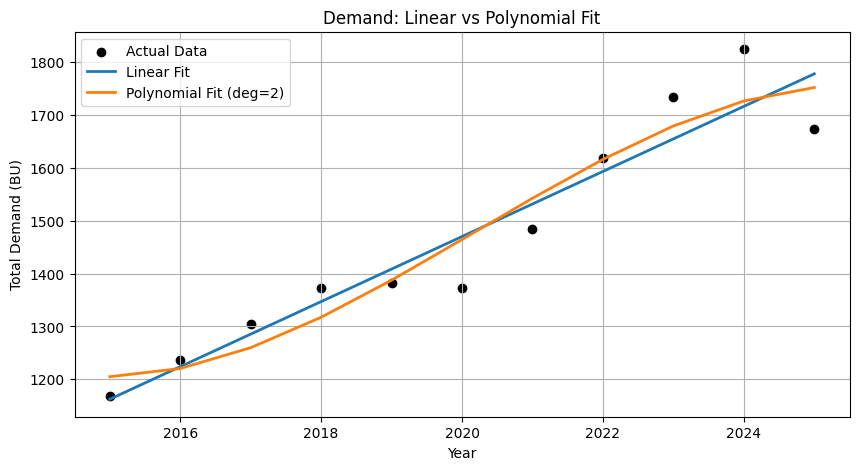

In [11]:


# X and y
X = df[['year']].values
y = df['total'].values

# Linear model
lin = LinearRegression()
lin.fit(X, y)
y_lin = lin.predict(X)

# Polynomial model (degree 2)
poly = make_pipeline(PolynomialFeatures(4), LinearRegression())
poly.fit(X, y)
y_poly = poly.predict(X)

# Plot
plt.figure(figsize=(10,5))
plt.scatter(df['year'], y, label="Actual Data", color="black")
plt.plot(df['year'], y_lin, label="Linear Fit", linewidth=2)
plt.plot(df['year'], y_poly, label="Polynomial Fit (deg=2)", linewidth=2)

plt.title("Demand: Linear vs Polynomial Fit")
plt.xlabel("Year")
plt.ylabel("Total Demand (BU)")
plt.legend()
plt.grid()
plt.show()

In [10]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# -----------------------------
# Helper function
# -----------------------------
def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse


# =============================
# 1. DEMAND MODEL
# =============================
X = df[['year']].values
y_demand = df['total'].values

# Linear
lin_demand = LinearRegression().fit(X, y_demand)
pred_lin_demand = lin_demand.predict(X)

# Polynomial (degree 2)
poly_demand = make_pipeline(PolynomialFeatures(4), LinearRegression())
poly_demand.fit(X, y_demand)
pred_poly_demand = poly_demand.predict(X)

# Metrics
lin_r2, lin_rmse = metrics(y_demand, pred_lin_demand)
poly_r2, poly_rmse = metrics(y_demand, pred_poly_demand)

print("\n=== DEMAND MODEL ===")
print("LINEAR     -> R2:", round(lin_r2,4), " RMSE:", round(lin_rmse,2))
print("POLYNOMIAL -> R2:", round(poly_r2,4), " RMSE:", round(poly_rmse,2))


# =============================
# 2. CUF MODELS
# =============================
sources = ['solar', 'wind', 'hydro', 'bio']

print("\n=== CUF MODELS (Linear vs Polynomial) ===")

for src in sources:
    y = df[f'cuf_{src}'].values

    # Linear
    lin = LinearRegression().fit(X, y)
    pred_lin = lin.predict(X)

    # Polynomial (degree 2)
    poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
    poly.fit(X, y)
    pred_poly = poly.predict(X)

    lin_r2, lin_rmse = metrics(y, pred_lin)
    poly_r2, poly_rmse = metrics(y, pred_poly)

    print(f"\n{src.upper()}")
    print("LINEAR     -> R2:", round(lin_r2,4), " RMSE:", round(lin_rmse,4))
    print("POLYNOMIAL -> R2:", round(poly_r2,4), " RMSE:", round(poly_rmse,4))


=== DEMAND MODEL ===
LINEAR     -> R2: 0.9068  RMSE: 62.36
POLYNOMIAL -> R2: 0.9195  RMSE: 57.95

=== CUF MODELS (Linear vs Polynomial) ===

SOLAR
LINEAR     -> R2: 0.1358  RMSE: 0.0186
POLYNOMIAL -> R2: 0.8075  RMSE: 0.0088

WIND
LINEAR     -> R2: 0.5886  RMSE: 0.0142
POLYNOMIAL -> R2: 0.8466  RMSE: 0.0087

HYDRO
LINEAR     -> R2: 0.001  RMSE: 0.2903
POLYNOMIAL -> R2: 0.4811  RMSE: 0.2092

BIO
LINEAR     -> R2: 0.5194  RMSE: 0.015
POLYNOMIAL -> R2: 0.5355  RMSE: 0.0147
